In [ ]:
# Dataset Shape
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Rows : 891
Columns : 8

Column Names:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load Dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Shape of Dataset

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 891
Number of Columns : 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Display first 10 rows

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# Display last 10 rows

df.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [ ]:
# Column Names

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
# Data Types

df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


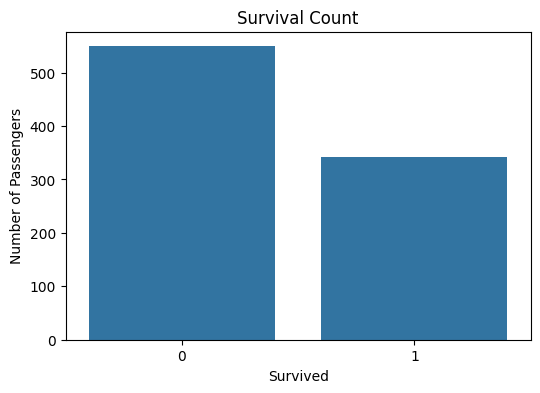

In [ ]:
# Survival Count

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

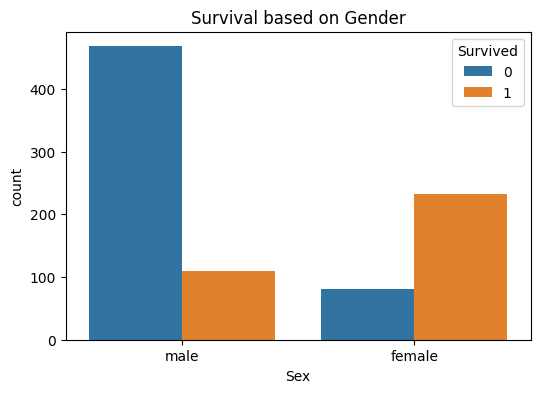

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival based on Gender")

plt.show()

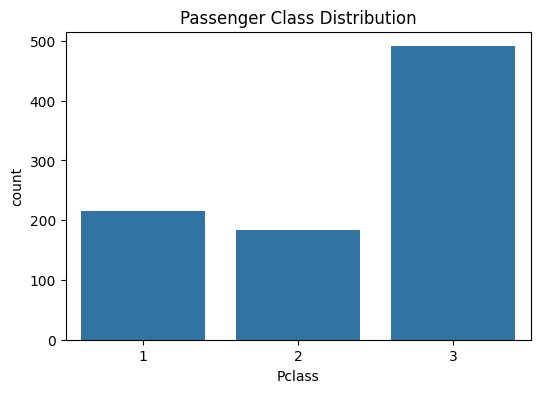

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df)

plt.title("Passenger Class Distribution")

plt.show()

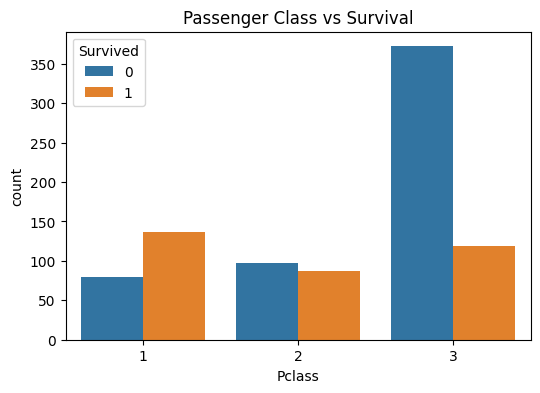

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival")

plt.show()

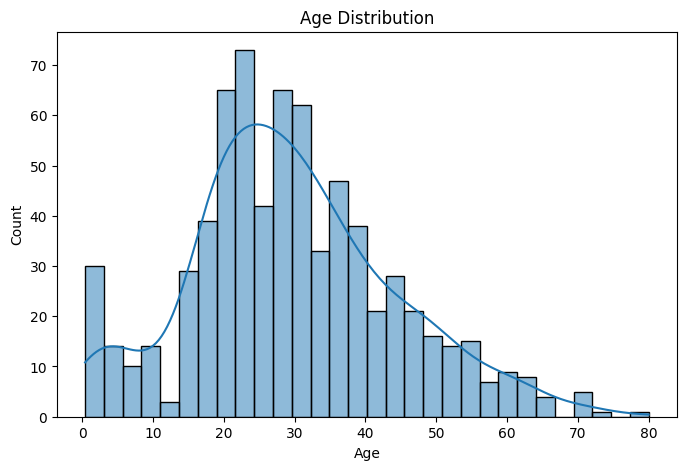

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

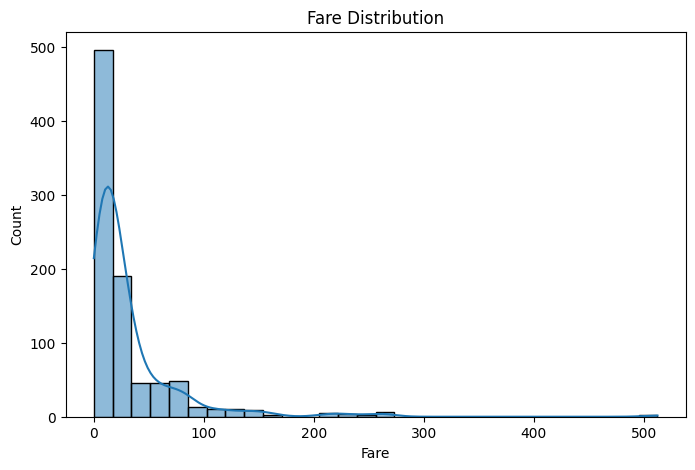

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

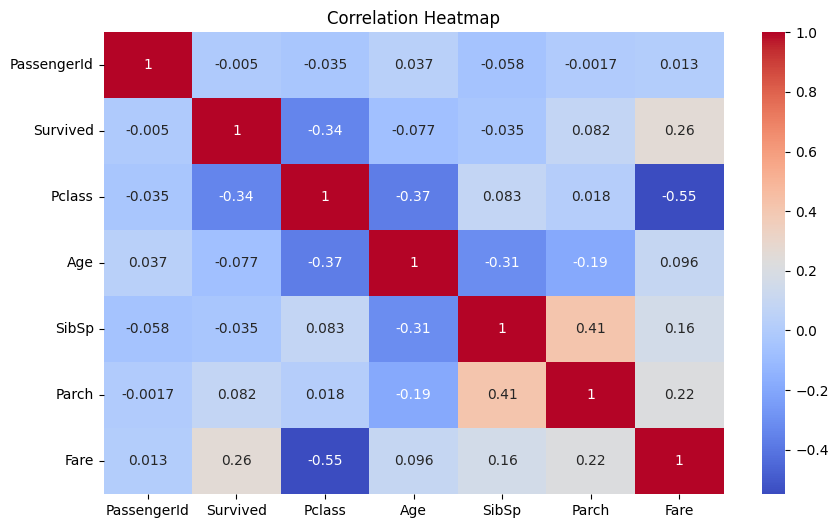

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

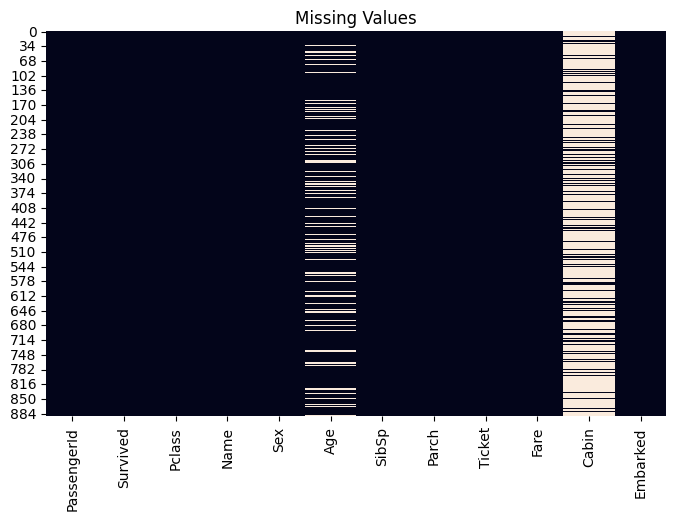

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [ ]:
# Missing Values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Fill missing Age values

df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
# Fill missing Embarked values

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
# Drop Cabin Column

df.drop("Cabin", axis=1, inplace=True)

In [ ]:
# Check Missing Values Again

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Convert Sex

df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [ ]:
# Convert Embarked

df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [ ]:
# Remove Unnecessary Columns

df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [ ]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [ ]:
# Features and Target

X = df.drop("Survived", axis=1)

y = df["Survived"]

In [ ]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (891, 7)
Target Shape : (891,)


In [ ]:
# Split Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (712, 7)
Testing Data : (179, 7)


# Machine Learning Model Building

In this section, three machine learning algorithms are trained and evaluated to predict passenger survival.

Models Used:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier


In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy : 79.89 %


In [ ]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



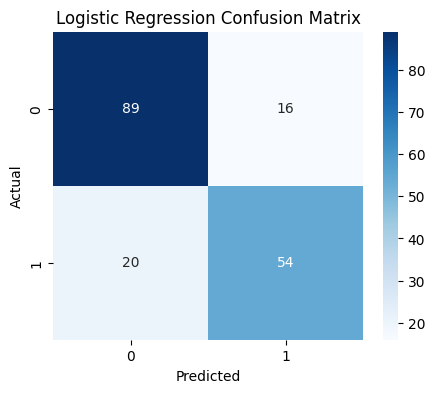

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2), "%")

Decision Tree Accuracy : 79.89 %


In [ ]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



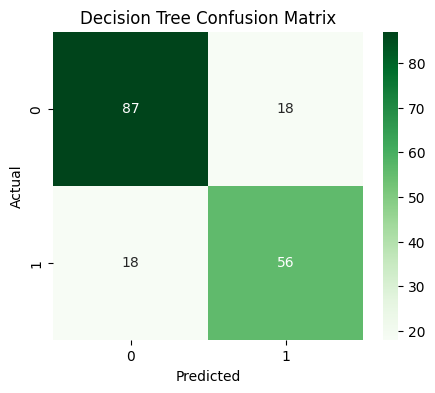

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 81.56 %


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



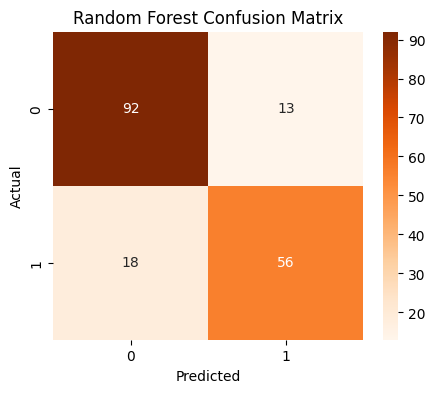

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Compare Model Accuracy

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results["Accuracy"] = results["Accuracy"]*100

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,Random Forest,82.681564
0,Logistic Regression,79.888268
1,Decision Tree,79.888268


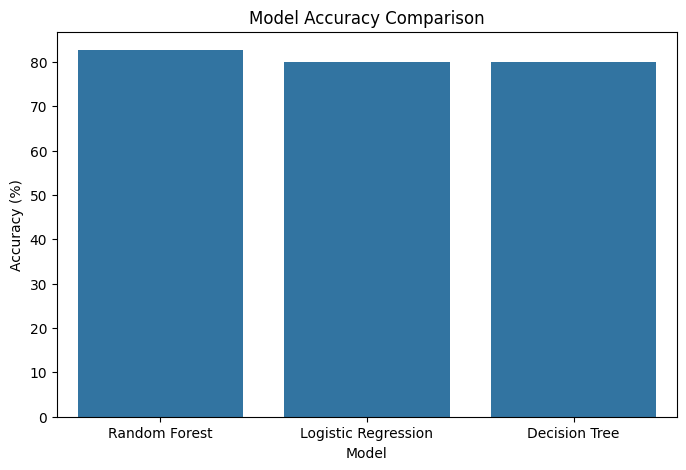

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Fare,0.269744
1,Sex,0.268418
2,Age,0.256426
0,Pclass,0.081891
3,SibSp,0.052077
4,Parch,0.037390
6,Embarked,0.034054


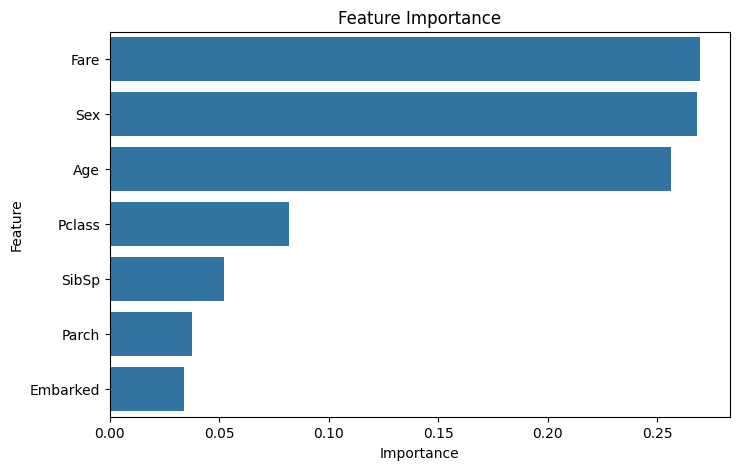

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [ ]:
best_model = results.iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],2),"%")

Best Model : Random Forest
Accuracy : 82.68 %


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Sex,0.452560
5,Fare,0.166551
0,Pclass,0.148858
2,Age,0.111624
3,SibSp,0.051679
4,Parch,0.037297
6,Embarked,0.031431


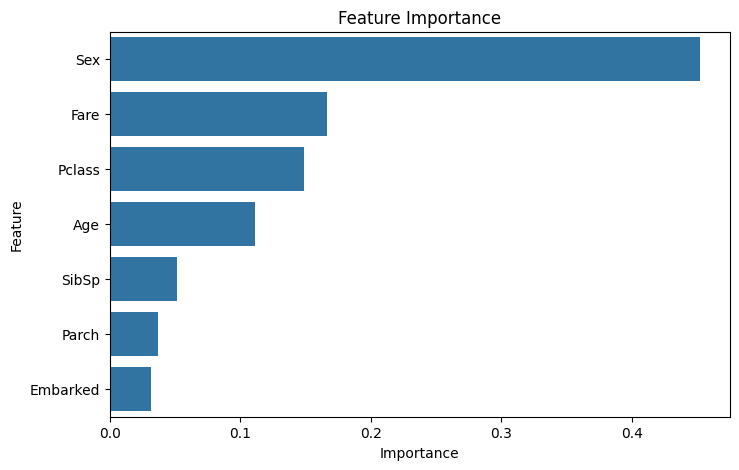

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [ ]:
# Predict a New Passenger

new_passenger = pd.DataFrame({
    "Pclass":[1],
    "Sex":[1],       # Female
    "Age":[25],
    "SibSp":[0],
    "Parch":[0],
    "Fare":[80],
    "Embarked":[1]   # Cherbourg
})

prediction = rf.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")

Prediction: Passenger Survived
